In [1]:
import jax
from temgym_core.components import Detector
from temgym_core.gaussian_action2D import (
    run_to_end,
    Lens,
    DistortedLens,
    make_gaussian_grid_input,
    Component2D
)
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
%matplotlib widget

jax.config.update("jax_enable_x64", True)

Understand how to make an input grid of lines like in principles of electron optics, to explain how pincushion/barrel distortion works.

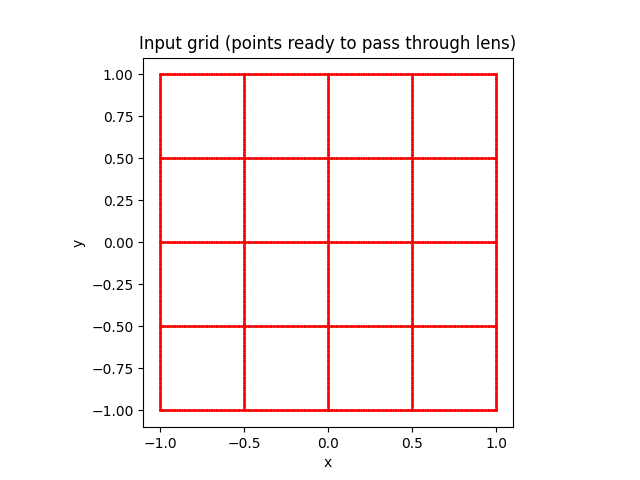

In [2]:
def make_grid_points(n_cells: int = 4, samples_per_line: int = 200, extent: float = 1.0):
    """
    Create a square grid like figure (A).
    Returns:
      points   : (N, 2) array of xy points for all grid lines
      line_ids : (N,) int array indicating which line each point belongs to
    """
    n_lines = n_cells + 1  # includes the outer square
    xs = np.linspace(-extent, extent, n_lines)
    ys = np.linspace(-extent, extent, n_lines)
    t = np.linspace(-extent, extent, samples_per_line)

    pts = []
    ids = []
    lid = 0

    # vertical lines (x fixed)
    for x in xs:
        pts.append(np.column_stack((np.full_like(t, x), t)))
        ids.append(np.full(samples_per_line, lid, dtype=np.int32))
        lid += 1

    # horizontal lines (y fixed)
    for y in ys:
        pts.append(np.column_stack((t, np.full_like(t, y))))
        ids.append(np.full(samples_per_line, lid, dtype=np.int32))
        lid += 1

    points = np.vstack(pts).astype(np.float32)
    line_ids = np.concatenate(ids)
    return points, line_ids

def plot_grid(points: np.ndarray, line_ids: np.ndarray, ax=None, color="k", lw=1.0):
    """Helper to plot the grid using the line_ids to keep lines connected."""
    if ax is None:
        _, ax = plt.subplots()
    for lid in np.unique(line_ids):
        seg = points[line_ids == lid]
        ax.plot(seg[:, 0], seg[:, 1], color=color, lw=lw)
    ax.set_aspect("equal")
    ax.set_xlim(points[:,0].min()*1.1, points[:,0].max()*1.1)
    ax.set_ylim(points[:,1].min()*1.1, points[:,1].max()*1.1)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    return ax

extent = 1.0
# Make a 4x4-cell grid (5x5 lines including the border) in [-1, 1] x [-1, 1]
grid_pts, grid_line_ids = make_grid_points(n_cells=4, samples_per_line=200, extent=extent)

# Preview (figure A-style)
ax = plot_grid(grid_pts, grid_line_ids)
ax.plot(grid_pts[:,0], grid_pts[:,1], 'o', color='red', markersize=1)
ax.set_title("Input grid (points ready to pass through lens)")
plt.show()

# Later, to apply a lens distortion, transform 'grid_pts' -> 'distorted_pts'
# distorted_pts = your_lens_function(grid_pts)  # same shape (N, 2)
# plot_grid(distorted_pts, grid_line_ids)

Show the various Seidel aberration function choices and visualise the Seidel phase plate:

In [3]:
# symbols
z1 = sp.symbols('z1')
xo, yo, xa, ya = sp.symbols('x_o y_o x_a y_a')
xop, yop, xap, yap = sp.symbols(r"x_o^{\prime} y_o^{\prime} x_a^{\prime} y_a^{\prime}", real=True)
A, B, C, D, E, F, e, f, c = sp.symbols('A B C D E F e f c')

# Aberration functions parametrized by different variables
def aber_object_pos_aperture_pos(xo, yo, xa, ya, coeffs):
    R = xo**2 + yo**2
    rho = xa**2 + ya**2
    chi = xo*xa + yo*ya
    sigma = xo*ya - yo*xa
    A, B, C, D, E, F, e, f, c = coeffs
    return (A*R**2 + B*rho**2 + C*chi**2 + D*R*rho + E*R*chi + F*rho*chi + e*R*sigma + f*rho*sigma + c*chi*sigma)

def aber_object_pos_object_slope(xo, yo, xop, yop, z1, coeffs):
    A, B, C, D, E, F, e, f, c = coeffs
    R = xo**2 + yo**2
    rho = (xo + xop*z1)**2 + (yo + yop*z1)**2
    chi = xo*(xo + xop*z1) + yo*(yo + yop*z1)
    sigma = xo*(yo + yop*z1) - yo*(xo + xop*z1)
    return (A*R**2 + B*rho**2 + C*chi**2 + D*R*rho + E*R*chi + F*rho*chi + e*R*sigma + f*rho*sigma + c*chi*sigma)

def aber_aperture_pos_aperture_slope(xa, ya, xap, yap, z1, coeffs):
    A, B, C, D, E, F, e, f, c = coeffs
    R = (xa - xap*z1)**2 + (ya - yap*z1)**2
    rho = xa**2 + ya**2
    chi = (xa - xap*z1)*xa + (ya - yap*z1)*ya
    sigma = (xa - xap*z1)*ya - (ya - yap*z1)*xa
    return (A*R**2 + B*rho**2 + C*chi**2 + D*R*rho + E*R*chi + F*rho*chi + e*R*sigma + f*rho*sigma + c*chi*sigma)

coeffs = (A, B, C, D, E, F, e, f, c)

W_xo_xa = aber_object_pos_aperture_pos(xo, yo, xa, ya, coeffs)
subs_map = {xa: xo + z1*xop, ya: yo + z1*yop}
W_xo_xthetao = sp.simplify(W_xo_xa.subs(subs_map))
subs_map = {xo: xa - z1*xap, yo: ya - z1*yap}
W_xa_xthetaa = sp.simplify(W_xo_xa.subs(subs_map))

display(W_xo_xa)
display(W_xo_xthetao.simplify())
display(W_xa_xthetaa.simplify())

W_xo_xthetao_from_func = aber_object_pos_object_slope(xo, yo, xop, yop, z1, coeffs)
W_xa_xthetaa_from_func = aber_aperture_pos_aperture_slope(xa, ya, xap, yap, z1, coeffs)

print(W_xo_xthetao.equals(W_xo_xthetao_from_func))
print(W_xa_xthetaa.equals(W_xa_xthetaa_from_func))


A*(x_o**2 + y_o**2)**2 + B*(x_a**2 + y_a**2)**2 + C*(x_a*x_o + y_a*y_o)**2 + D*(x_a**2 + y_a**2)*(x_o**2 + y_o**2) + E*(x_o**2 + y_o**2)*(x_a*x_o + y_a*y_o) + F*(x_a**2 + y_a**2)*(x_a*x_o + y_a*y_o) + c*(x_a*x_o + y_a*y_o)*(-x_a*y_o + x_o*y_a) + e*(x_o**2 + y_o**2)*(-x_a*y_o + x_o*y_a) + f*(x_a**2 + y_a**2)*(-x_a*y_o + x_o*y_a)

A*(x_o**2 + y_o**2)**2 + B*((x_o + x_o^{\prime}*z1)**2 + (y_o + y_o^{\prime}*z1)**2)**2 + C*(x_o*(x_o + x_o^{\prime}*z1) + y_o*(y_o + y_o^{\prime}*z1))**2 + D*(x_o**2 + y_o**2)*((x_o + x_o^{\prime}*z1)**2 + (y_o + y_o^{\prime}*z1)**2) + E*(x_o**2 + y_o**2)*(x_o*(x_o + x_o^{\prime}*z1) + y_o*(y_o + y_o^{\prime}*z1)) + F*(x_o*(x_o + x_o^{\prime}*z1) + y_o*(y_o + y_o^{\prime}*z1))*((x_o + x_o^{\prime}*z1)**2 + (y_o + y_o^{\prime}*z1)**2) + c*(x_o*(x_o + x_o^{\prime}*z1) + y_o*(y_o + y_o^{\prime}*z1))*(x_o*(y_o + y_o^{\prime}*z1) - y_o*(x_o + x_o^{\prime}*z1)) + e*(x_o**2 + y_o**2)*(x_o*(y_o + y_o^{\prime}*z1) - y_o*(x_o + x_o^{\prime}*z1)) + f*(x_o*(y_o + y_o^{\prime}*z1) - y_o*(x_o + x_o^{\prime}*z1))*((x_o + x_o^{\prime}*z1)**2 + (y_o + y_o^{\prime}*z1)**2)

A*((x_a - x_a^{\prime}*z1)**2 + (y_a - y_a^{\prime}*z1)**2)**2 + B*(x_a**2 + y_a**2)**2 + C*(x_a*(x_a - x_a^{\prime}*z1) + y_a*(y_a - y_a^{\prime}*z1))**2 + D*(x_a**2 + y_a**2)*((x_a - x_a^{\prime}*z1)**2 + (y_a - y_a^{\prime}*z1)**2) + E*(x_a*(x_a - x_a^{\prime}*z1) + y_a*(y_a - y_a^{\prime}*z1))*((x_a - x_a^{\prime}*z1)**2 + (y_a - y_a^{\prime}*z1)**2) + F*(x_a**2 + y_a**2)*(x_a*(x_a - x_a^{\prime}*z1) + y_a*(y_a - y_a^{\prime}*z1)) - c*(x_a*(x_a - x_a^{\prime}*z1) + y_a*(y_a - y_a^{\prime}*z1))*(x_a*(y_a - y_a^{\prime}*z1) - y_a*(x_a - x_a^{\prime}*z1)) - e*(x_a*(y_a - y_a^{\prime}*z1) - y_a*(x_a - x_a^{\prime}*z1))*((x_a - x_a^{\prime}*z1)**2 + (y_a - y_a^{\prime}*z1)**2) - f*(x_a**2 + y_a**2)*(x_a*(y_a - y_a^{\prime}*z1) - y_a*(x_a - x_a^{\prime}*z1))

True
True


Text(0.5, 1.0, 'W (aperture pos, aperture slope)')

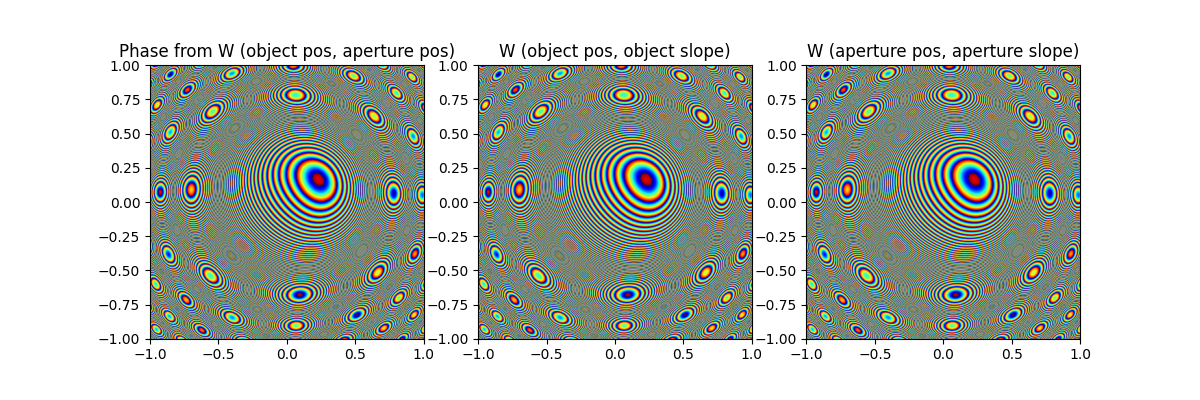

In [4]:

xa = np.linspace(-extent, extent, 400)
ya = np.linspace(-extent, extent, 400)
Xa, Ya = np.meshgrid(xa, ya)
xo, yo = 0.0, 0.7  # on-axis object point
z1 = 0.5
x_slope = (Xa - xo) / z1
y_slope = (Ya - yo) / z1

A = 10
B = 10
C = 1
D = 5
E = 4
F = 2
c = 1
e = 5
f = 1

W_opos_apos = aber_object_pos_aperture_pos(xo, yo, Xa, Ya, coeffs=(A, B, C, D, E, F, e, f, c))
W_opos_oslope = aber_object_pos_object_slope(xo, yo, x_slope, y_slope, z1, coeffs=(A, B, C, D, E, F, e, f, c))
W_apos_aslope = aber_aperture_pos_aperture_slope(Xa, Ya, (Xa - xo)/z1, (Ya - yo)/z1, z1, coeffs=(A, B, C, D, E, F, e, f, c))

wavelength = 0.1
k = 2 * np.pi / wavelength
chi_oa = np.exp(1j * k * W_opos_apos)
chi_o_os = np.exp(1j * k * W_opos_oslope)
chi_a_as = np.exp(1j * k * W_apos_aslope)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
im0 = axs[0].imshow(np.angle(chi_oa), extent=(-extent, extent, -extent, extent), cmap='jet')
axs[0].set_title("Phase from W (object pos, aperture pos)")
im1 = axs[1].imshow(np.angle(chi_o_os), extent=(-extent, extent, -extent, extent), cmap='jet')
axs[1].set_title("W (object pos, object slope)")
im2 = axs[2].imshow(np.angle(chi_a_as), extent=(-extent, extent, -extent, extent), cmap='jet')
axs[2].set_title("W (aperture pos, aperture slope)")

Make a distorted projector lens and, and an input grid of gaussians to see how the distortion affects the image.

In [20]:
gaussians_in = make_gaussian_grid_input(waist=5e-8,
                                        voltage=100e3,
                                        z0=0.0,
                                        amp=1.0,
                                        phase=0.0,
                                        n_cells=3,
                                        samples_per_line=1000,
                                        extent=1e-6)

input_detector = Detector(z=0.0, pixel_size = (1e-8, 1e-8), shape=(512, 512))
input_extent = input_detector.extent
grid_image = evaluate_gaussians_gpu_kernel_wrapper(gaussians_in, input_detector)

f = 1e-3
M = -10
z1 = f * (1 - 1 / M)
z2 = f * (1 - M)
z1 = abs(z1)
z2 = abs(z2)
print(f"z1 = {z1:.4e} m, z2 = {z2:.4e} m")

distortion_lens = DistortedLens(focal_length=f, z=z1, z1=z1, E=-3e13)
output_detector = Detector(z=z1+z2, pixel_size = (1e-8 * M, 1e-8 * M), shape=(512, 512))
output_extent = output_detector.extent

run_to_end_jit = jax.jit(run_to_end)
run_to_end_vmapped = jax.jit(
    jax.vmap(run_to_end_jit, in_axes=(0, None)),
    static_argnums=(1,),
)

gaussians_out = run_to_end_vmapped(
    gaussians_in, (distortion_lens, output_detector),
)

output_image = evaluate_gaussians_gpu_kernel_wrapper(gaussians_out, output_detector)

z1 = 1.1000e-03 m, z2 = 1.1000e-02 m


Text(0.5, 1.0, 'Input grid intensity (after lens)')

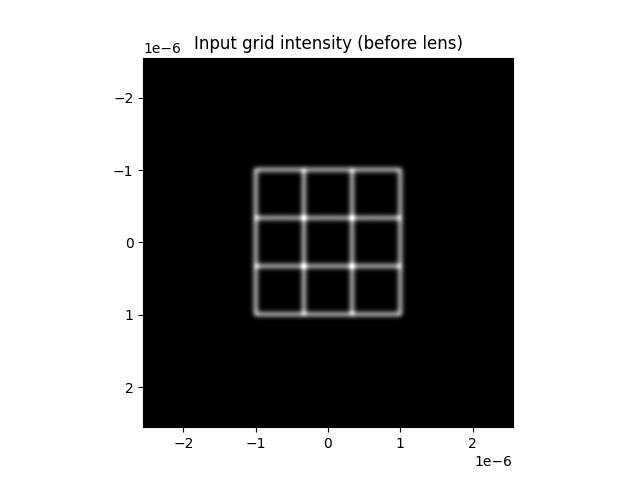

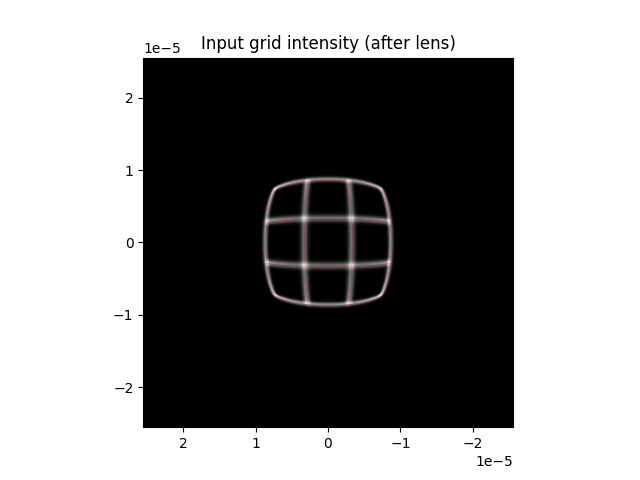

In [21]:
plt.figure()

plt.imshow(jnp.abs(grid_image), extent=input_extent, cmap='gray')
plt.title("Input grid intensity (before lens)")

plt.figure()
plt.imshow(jnp.abs(output_image), extent=output_extent, cmap='gray')
plt.plot(gaussians_out.x, gaussians_out.y, 'ro', markersize=0.4, alpha = 0.01)
plt.title("Input grid intensity (after lens)")